# Μοντέλο Χρήσης Ανακυκλούμενης Πιστωτικής Γραμμής Μικρών Επιχειρήσεων

## Σύνοψη για Στελέχη

Οι ανακυκλούμενες πιστωτικές γραμμές είναι δεσμευμένες αλλά όχι πλήρως αντληθείσες, οπότε το **χρηματοδοτούμενο υπόλοιπο** ενός δανειστή — και το οικονομικό κεφάλαιο που πρέπει να διακρατεί — εξαρτάται από το πόσο μεγάλο μέρος κάθε γραμμής χρησιμοποιεί πραγματικά ο δανειολήπτης. Η ανάλυση αυτή μοντελοποιεί τον **ρυθμό χρήσης** (αντληθέν υπόλοιπο / δεσμευμένο όριο) για ένα δείγμα εργασίας από **100 ανακυκλούμενες γραμμές μικρών επιχειρήσεων** ώστε να προβλέψει τη χρηματοδοτούμενη έκθεση και να υποστηρίξει τον σχεδιασμό κεφαλαίου.

Συνδυάζουμε τέσσερις διαδικασίες SAS, καθεμία απαντώντας σε μια διακριτή ερώτηση σχεδιασμού:

- Η **PROC MEANS** σκιαγραφεί το αντληθέν υπόλοιπο και τη χρήση ανά εσωτερική **βαθμίδα κινδύνου**. Η μέση χρήση αυξάνεται μονότονα κατά μήκος των βαθμίδων — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E) — καθιερώνοντας την εμπειρική σχέση πιστωτικής ποιότητας προς χρήση που τροφοδοτεί τις παραδοχές έκθεσης σε αθέτηση.
- Η **PROC REG** προσαρμόζει τη χρήση έναντι των θεμελιωδών μεγεθών του δανειολήπτη (κάλυψη εξυπηρέτησης χρέους, μεταβλητότητα εσόδων, ωρίμανση γραμμής, προηγούμενη χρήση) και του μακροοικονομικού περιβάλλοντος (ανεργία, βραχυπρόθεσμο επιτόκιο). Το μοντέλο εξηγεί το 45% της διακύμανσης (R-Square 0.448, F p < .0001), και οι τυποποιημένες εκτιμήσεις κατατάσσουν την **κάλυψη εξυπηρέτησης χρέους** (-0.45) και την **προηγούμενη χρήση** (0.41) ως τους κυρίαρχους παράγοντες. Όλοι οι συντελεστές διόγκωσης διακύμανσης παραμένουν κάτω από 1.17, οπότε η πολυσυγγραμμικότητα δεν αποτελεί ανησυχία.
- Η **PROC GLM** ελέγχει αν η χρήση διαφέρει ανά **κλάδο δραστηριότητας** αφού ελεγχθούν αυτοί οι παράγοντες, χρησιμοποιώντας μέσους ελαχίστων τετραγώνων προσαρμοσμένους κατά Tukey. Η επίδραση του κλάδου είναι οριακή συνολικά (F p = 0.060), αλλά ο κλάδος **Κατασκευών** αντλεί σημαντικά περισσότερα από το **Λιανικό Εμπόριο** (p = 0.007) και την **Υγειονομική Περίθαλψη** (p = 0.024) όταν κρατείται σταθερή η ποιότητα του δανειολήπτη.
- Η **PROC UNIVARIATE** εξάγει τα εκατοστημόρια χρήσης 2.5 και 97.5 — μια ζώνη **0.121 έως 0.744** γύρω από έναν μέσο 0.404 — ορίζοντας το εύλογο σενάριο χαμηλής/υψηλής άντλησης για δοκιμές ακραίων καταστάσεων και οικονομικού κεφαλαίου.

Μαζί, τα αποτελέσματα αυτά επιτρέπουν στην τράπεζα να μεταφράσει ένα στατικό βιβλίο δεσμευμένων ορίων σε μια **προβλεπτική πρόβλεψη χρηματοδοτούμενου υπολοίπου** με υπερασπίσιμες, ελέγξιμες παραδοχές. Το δείγμα των 100 γραμμών είναι το τμήμα που εκτελεί αυτό το περιβάλλον· το ίδιο πρόγραμμα κλιμακώνεται αμετάβλητο σε ένα πλήρες παραγωγικό βιβλίο.

## Πηγές Δεδομένων

Το σύνολο δεδομένων παράγεται συνθετικά εντός του notebook (χωρίς εξωτερικά αρχεία, χωρίς δίκτυο). Κάθε γραμμή είναι μία ανακυκλούμενη πιστωτική γραμμή μικρής επιχείρησης παρατηρούμενη σε μια χρονική στιγμή.

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `line_id` | Num | Μοναδικό αναγνωριστικό πιστωτικής γραμμής |
| `risk_grade` | Char | Εσωτερική βαθμίδα κινδύνου (A καλύτερη … E ασθενέστερη) |
| `industry` | Char | Κλάδος δραστηριότητας δανειολήπτη (Λιανικό Εμπόριο, Υπηρεσίες, Κατασκευές, Μεταποίηση, Υγειονομική Περίθαλψη) |
| `committed_limit` | Num | Δεσμευμένο ποσό πιστωτικής γραμμής ($000άδες) |
| `months_on_book` | Num | Ωρίμανση γραμμής (μήνες από την έναρξη) |
| `dscr` | Num | Δείκτης κάλυψης εξυπηρέτησης χρέους |
| `rev_volatility` | Num | Μεταβλητότητα εσόδων προηγούμενης περιόδου (συντελεστής μεταβλητότητας) |
| `prior_util` | Num | Ρυθμός χρήσης στην προηγούμενη περίοδο (0–1) |
| `unemp_rate` | Num | Τοπικό ποσοστό ανεργίας (%) κατά την ημερομηνία παρατήρησης |
| `short_rate` | Num | Επικρατούν βραχυπρόθεσμο επιτόκιο αναφοράς (%) |
| `utilization_rate` | Num | Αντληθέν υπόλοιπο / δεσμευμένο όριο (0–1), η μοντελοποιούμενη απόκριση |
| `drawn_balance` | Num | Χρηματοδοτούμενο υπόλοιπο = utilization_rate × committed_limit ($000άδες) |

**Κλίμακα:** το βήμα DATA είναι γραμμένο ώστε να παράγει ένα πλήρες βιβλίο, αλλά αυτό το περιβάλλον εκτελείται χωρίς άδεια και περιορίζει την έξοδο στις πρώτες **100 γραμμές** — το δείγμα εργασίας που αναλύεται καθ' όλη τη διάρκεια. Αυτές οι 100 γραμμές καλύπτουν και τις 5 βαθμίδες κινδύνου (A–E) και τους 5 κλάδους δραστηριότητας. Η χρήση προσομοιώνεται από μια λανθάνουσα μεταβλητή συνδεδεμένη με logit που καθοδηγείται από τις παραπάνω συμμεταβλητές συν θόρυβο, οπότε η παλινδρόμηση και το GLM ανακτούν γνήσιο, ερμηνεύσιμο σήμα. Ο χρόνος εκτέλεσης είναι αρκετά κάτω από 60 δευτερόλεπτα.

## 1. Δημιουργία του συνθετικού χαρτοφυλακίου πιστωτικών γραμμών

Το πρώτο κελί κατασκευάζει ένα ρεαλιστικό βιβλίο ανακυκλούμενων γραμμών μικρών επιχειρήσεων (αυτό το περιβάλλον περιορίζει την εκτέλεση στις πρώτες **100 γραμμές**). Αντλούμε μια βαθμίδα κινδύνου και έναν κλάδο δραστηριότητας για κάθε γραμμή, στη συνέχεια προσομοιώνουμε τα θεμελιώδη μεγέθη του δανειολήπτη και το μακροοικονομικό περιβάλλον. Η χρήση παράγεται από μια **λανθάνουσα βαθμολογία συνδεδεμένη με logit** ώστε οι ασθενέστερες βαθμίδες, η χαμηλότερη κάλυψη εξυπηρέτησης χρέους, η υψηλότερη μεταβλητότητα εσόδων, η πιο επίμονη προηγούμενη χρήση και ένα καταπονημένο μακροοικονομικό υπόβαθρο να ωθούν όλα το αντληθέν κλάσμα προς τα πάνω — ακριβώς η δομή που η παλινδρόμηση και το GLM παρακάτω προορίζονται να ανακτήσουν. Το χρηματοδοτούμενο `drawn_balance` προκύπτει τότε ως η χρήση επί το δεσμευμένο όριο.

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού χαρτοφυλακίου ανακυκλούμενων
   πιστωτικών γραμμών μικρών επιχειρήσεων. Η χρήση προσομοιώνεται
   από ένα λανθάνον μέγεθος με σύνδεσμο logit, οδηγούμενο από
   πιστωτικές, δανειοληπτικές και μακροοικονομικές συμμεταβλητές,
   ώστε τα παρακάτω μοντέλα να ανακτούν πραγματικό σήμα.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ credit_lines;
    CALL streaminit(20260605);

    ΕΤΙΚΕΤΑ line_id          = "Αναγνωριστικό πιστωτικής γραμμής"
          risk_grade       = "Εσωτερική βαθμίδα κινδύνου (A-E)"
          industry         = "Κλάδος δραστηριότητας δανειολήπτη"
          committed_limit  = "Δεσμευμένο όριο (χιλ. $)"
          months_on_book   = "Παλαίωση γραμμής (μήνες)"
          dscr             = "Δείκτης κάλυψης εξυπηρέτησης χρέους"
          rev_volatility   = "Μεταβλητότητα εσόδων (CV)"
          prior_util       = "Ρυθμός χρήσης προηγούμενης περιόδου"
          unemp_rate       = "Τοπικό ποσοστό ανεργίας (%)"
          short_rate       = "Βραχυπρόθεσμο επιτόκιο αναφοράς (%)"
          utilization_rate = "Ρυθμός χρήσης (αντληθέν/όριο)"
          drawn_balance    = "Χρηματοδοτούμενο υπόλοιπο (χιλ. $)";

    /* Πίνακες αναζήτησης για κατηγορικά χαρακτηριστικά */
    ARRAY grades[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    ARRAY segs[5] $20 _temporary_
        ('Λιανική' 'Υπηρεσίες' 'Κατασκευές'
         'Μεταποίηση' 'Υγεία');

    ΕΠΑΝΑΛΗΨΗ line_id = 1 ΕΩΣ 4000;

        /* Βαθμίδα κινδύνου: περισσότερη μάζα στις μεσαίες βαθμίδες */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        risk_grade = grades[g];

        /* Κλάδος: σχεδόν ομοιόμορφος με κλίση προς τη λιανική */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        industry = segs[s];

        /* Δεσμευμένο όριο: λογαριθμοκανονικό, $25χιλ έως ~$1.5εκ */
        committed_limit = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Θεμελιώδη μεγέθη δανειολήπτη */
        months_on_book = round(rand('UNIFORM') * 84 + 3, 1);
        dscr           = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        rev_volatility = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        prior_util     = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Μακροοικονομικό περιβάλλον κατά την ημερομηνία παρατήρησης */
        unemp_rate = round(rand('NORMAL', 5.2, 1.1), 0.1);
        ΕΑΝ unemp_rate < 2.5 ΤΟΤΕ unemp_rate = 2.5;
        short_rate = round(rand('NORMAL', 4.0, 0.8), 0.01);
        ΕΑΝ short_rate < 0 ΤΟΤΕ short_rate = 0;

        /* Δείκτης σοβαρότητας βαθμίδας: A=0 ... E=4 */
        grade_sev = g - 1;

        /* Λανθάνον σκορ χρήσης με σύνδεσμο logit.
           Ασθενέστερες βαθμίδες, χαμηλότερο DSCR, υψηλότερη
           μεταβλητότητα, επίμονη προηγούμενη χρήση και μακρο-
           οικονομικό στρες αυξάνουν τη χρήση. */
        eta = -0.60
              + 0.34 * grade_sev
              - 0.55 * (dscr - 1.4)
              + 1.10 * (rev_volatility - 0.24)
              + 1.80 * (prior_util - 0.45)
              + 0.16 * (unemp_rate - 5.2)
              + 0.07 * (short_rate - 4.0)
              - 0.004 * (months_on_book - 40);

        /* Μετατοπίσεις ανά κλάδο στη λανθάνουσα κλίμακα */
        ΕΠΙΛΟΓΗ (industry);
            ΟΤΑΝ ('Κατασκευές')  eta = eta + 0.30;
            ΟΤΑΝ ('Λιανική')     eta = eta + 0.12;
            ΟΤΑΝ ('Μεταποίηση')  eta = eta - 0.08;
            ΟΤΑΝ ('Υγεία')       eta = eta - 0.22;
            ΑΛΛΟ; /* Υπηρεσίες = αναφορά */
        ΤΕΛΟΣ;

        /* Προσθήκη θορύβου, χαρτογράφηση στο (0,1) μέσω logistic */
        eta = eta + rand('NORMAL', 0, 0.45);
        utilization_rate = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Το χρηματοδοτούμενο υπόλοιπο προκύπτει από τη χρήση */
        drawn_balance = round(utilization_rate * committed_limit,
                              0.1);

        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ line_id risk_grade industry committed_limit
         months_on_book dscr rev_volatility prior_util
         unemp_rate short_rate utilization_rate drawn_balance;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA credit_lines

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote credit_lines (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.50 seconds
  cpu   1.50 seconds


## 2. Χρηματοδοτούμενη έκθεση ανά βαθμίδα κινδύνου

Τα μοντέλα οικονομικού κεφαλαίου χρειάζεται να γνωρίζουν πώς το χρηματοδοτούμενο υπόλοιπο και η χρήση μεταβάλλονται μεταξύ των βαθμίδων πιστωτικής ποιότητας. Η **PROC MEANS** συνοψίζει το αντληθέν υπόλοιπο και τη χρήση για κάθε εσωτερική βαθμίδα κινδύνου με την πλήρη κατανομική εικόνα — μέσο, τυπική απόκλιση, τεταρτημόρια και εύρος. Αναμένουμε η χρήση να ανεβαίνει μονότονα από τη βαθμίδα A στη βαθμίδα E, γεγονός που τροφοδοτεί άμεσα τις παραδοχές έκθεσης σε αθέτηση για το ανακυκλούμενο βιβλίο.

In [2]:
/* Αντληθέν υπόλοιπο και χρήση ανά εσωτερική βαθμίδα κινδύνου */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=credit_lines NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    ΚΛΑΣΗ risk_grade;
    ΜΕΤΑΒΛΗΤΗ drawn_balance utilization_rate committed_limit;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

            Analysis Variable : drawn_balance Χρηματοδοτούμενο υπόλοιπο (χιλ. $)

        Εσωτερική βαθμίδα κινδύνου (A-E)                                  N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        A                                                                    18         40.533         24.606          5.900          25.500         36.050          50.200        103.300
        B                                                                    26         42.450         25.148          7.000          25.200         31.400          62.000         99.900
        C                                                                    29         55.552     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Παράγοντες της χρήσης — πολλαπλή παλινδρόμηση

Η **PROC REG** μοντελοποιεί τον ρυθμό χρήσης έναντι των θεμελιωδών μεγεθών του δανειολήπτη και του μακροοικονομικού περιβάλλοντος. Ζητούμε:

- **CLB** — 95% όρια εμπιστοσύνης για κάθε συντελεστή, ώστε η ομάδα πιστώσεων να μπορεί να αναφέρει εύρη επίδρασης αντί για σημειακές εκτιμήσεις.
- **VIF** και **TOL** — συντελεστές διόγκωσης διακύμανσης και ανοχή για επιβεβαίωση ότι οι συμμεταβλητές δεν είναι συγγραμμικές.
- **STB** — τυποποιημένες εκτιμήσεις για κατάταξη των παραγόντων σε συγκρίσιμη κλίμακα.

Οι συντελεστές απαντούν άμεσα στην ερώτηση σχεδιασμού: κατά πόσο μια μεταβολή μιας μονάδας σε κάθε παράγοντα αλλάζει το αναμενόμενο αντληθέν κλάσμα μιας γραμμής; Το προσαρμοσμένο μοντέλο εξηγεί το 45% της διακύμανσης της χρήσης (R-Square 0.448, συνολικό F p < .0001). Η PROC REG εκπέμπει επίσης το τυπικό της διαγνωστικό πλαίσιο ODS — υπόλοιπα έναντι προβλεπόμενων, ένα ιστόγραμμα υπολοίπων, υπόλοιπα έναντι σειράς παρατήρησης, ένα κανονικό διάγραμμα Q-Q και ένα διάγραμμα επιρροής Cook's D — που εμφανίζεται κάτω από τον πίνακα. Η διαδικασία είναι μια διαδραστική διαδικασία ομάδας RUN, οπότε την κλείνουμε με `quit;` για να εκκενώσουμε την έξοδο.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
               Dependent Variable: utilization_rate Ρυθμός χρήσης (αντληθέν/όριο)               

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.26845      0.21141     12.07    <.0001
Error                  93         1.62938      0.01752                    
Corrected Total        99         2.89783                                 

Root MSE           0.13236    R-Square            0.4377
Dependent Mean       0.39845    Adj R-Sq            0.4014
Coeff Var         33.21954

                                                                                                              Parameter Estimates           


NOTE: PROC REG data=credit_lines

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


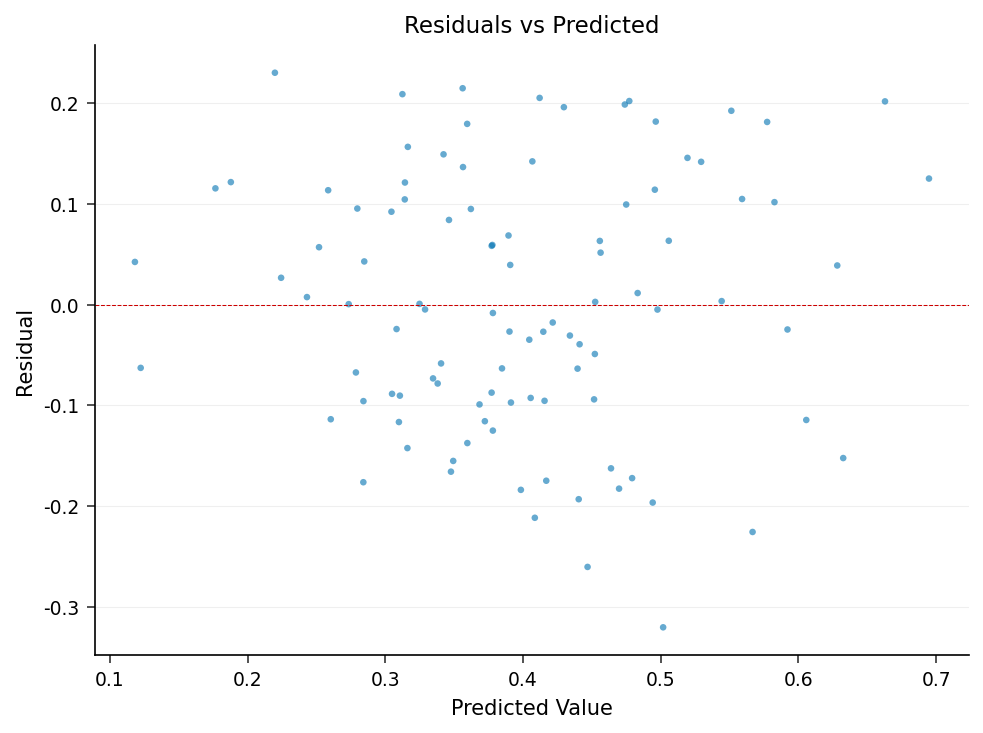

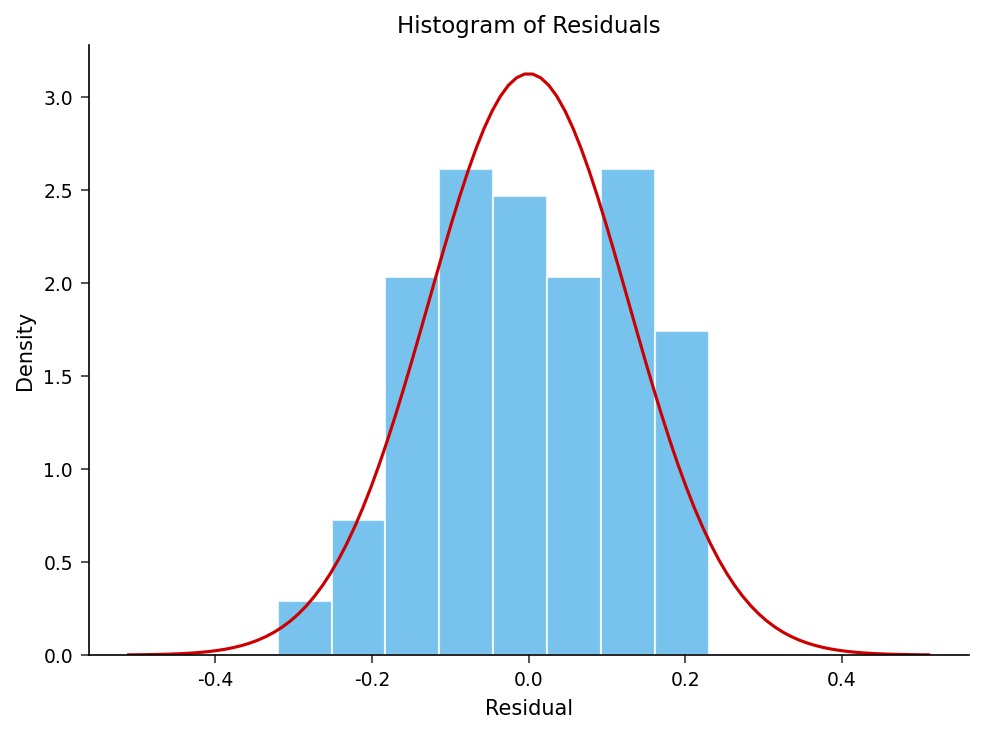

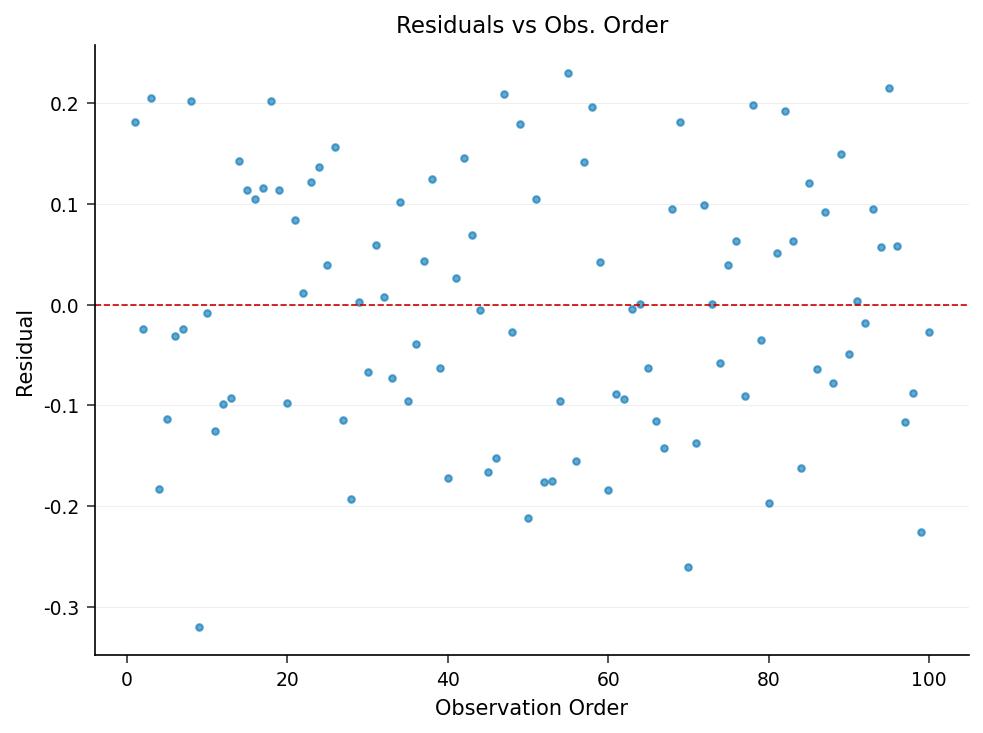

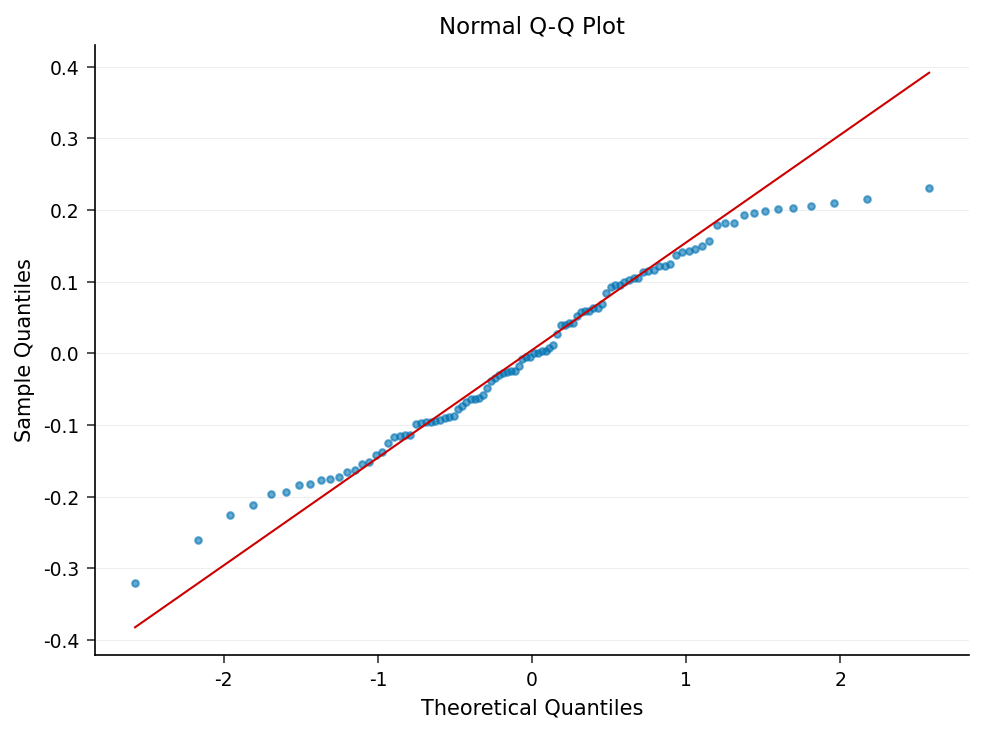

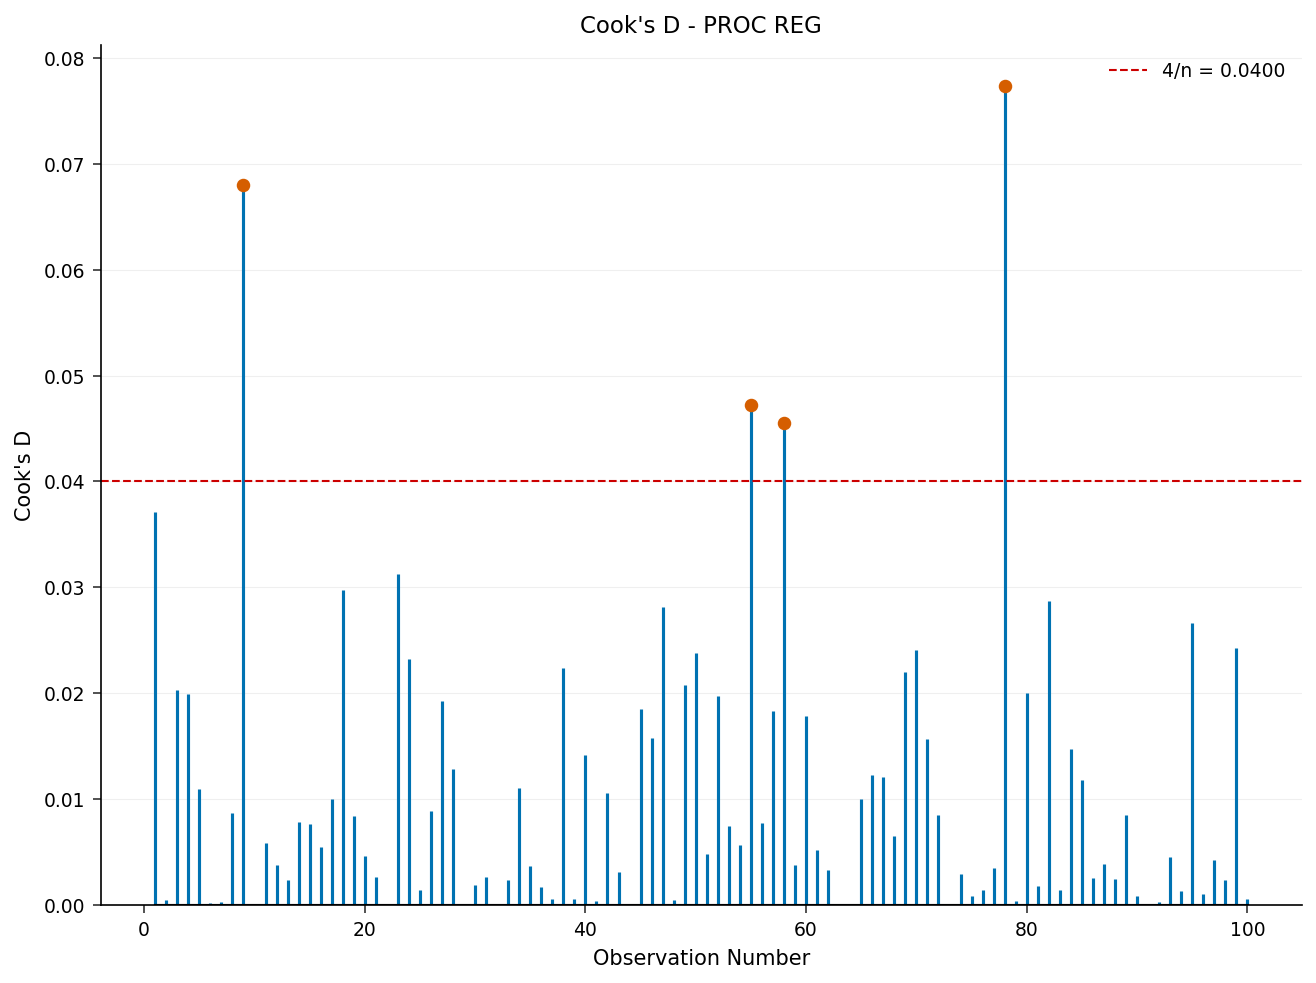

In [3]:
/* Ρυθμός χρήσης έναντι δανειοληπτικών και μακροοικονομικών συμμεταβλητών */
ΔΙΑΔΙΚΑΣΙΑ REG ΔΕΔΟΜΕΝΑ=credit_lines;
    ΜΟΝΤΕΛΟ utilization_rate =
          dscr rev_volatility prior_util
          months_on_book unemp_rate short_rate
          / clb stb vif tol;
ΕΚΤΕΛΕΣΗ;
QUIT;

## 4. Χρήση ανά κλάδο δραστηριότητας — γενικό γραμμικό μοντέλο

Αντλούν κάποιοι κλάδοι τις γραμμές τους πιο επιθετικά αφού λάβουμε υπόψη την ποιότητα του δανειολήπτη και το μακροοικονομικό υπόβαθρο; Η **PROC GLM** αντιμετωπίζει το `industry` ως επίδραση ταξινόμησης και προσθέτει τις ίδιες συνεχείς συμμεταβλητές ως ελέγχους ανάλυσης συνδιακύμανσης. Ζητούμε:

- **SOLUTION** — τις εκτιμήσεις παραμέτρων για κάθε επίπεδο κλάδου σε σχέση με το επίπεδο αναφοράς.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — μέσους ελαχίστων τετραγώνων προσαρμοσμένους κατά Tukey και ανά ζεύγη διαφορές, τη χρήση προσαρμοσμένη ως προς τις συμμεταβλητές για κάθε κλάδο.

Το GLM εκπέμπει το ίδιο διαγνωστικό πλαίσιο ODS με το REG συν ένα ραβδόγραμμα μέσων ελαχίστων τετραγώνων ανά κλάδο (με διαστήματα εμπιστοσύνης), που εμφανίζεται κάτω από τους πίνακες. Είναι επίσης μια διαδικασία ομάδας RUN, οπότε τελειώνει με `quit;`.

                            The GLM Procedure                            
Dependent Variable: utilization_rate Ρυθμός χρήσης (αντληθέν/όριο)

Source                DF  Sum of Squares  Mean Square   F Value    Pr > F
--------------  --------  --------------  -----------  --------  --------
industry               4         0.12603      0.03151      1.86    0.1244
dscr                   1         0.65370      0.65370     38.58    <.0001
rev_volatility         1         0.12603      0.12603      7.44    0.0077
prior_util             1         0.41971      0.41971     24.77    <.0001
unemp_rate             1         0.13577      0.13577      8.01    0.0057
short_rate             1         0.08943      0.08943      5.28    0.0239
Error                 90         1.52487      0.01694                    

Root MSE           0.13017    R-Square            0.4738
Adj R-Sq            0.4212

                                     Parameter Estimates                                      

Parameter 


NOTE: PROC GLM data=credit_lines

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_industry.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


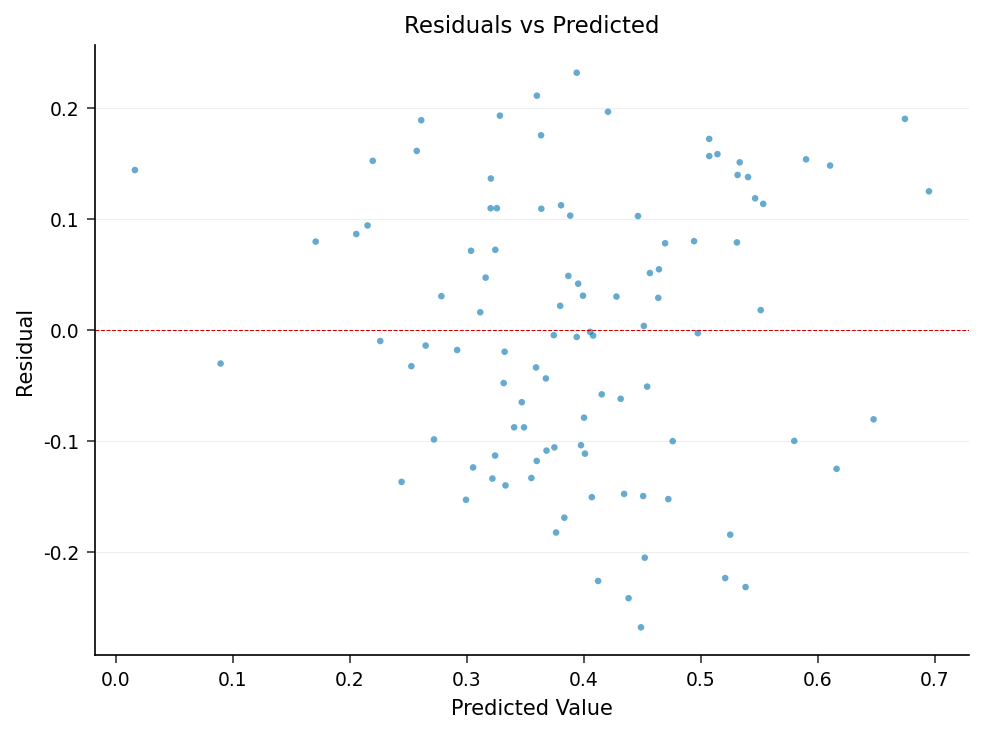

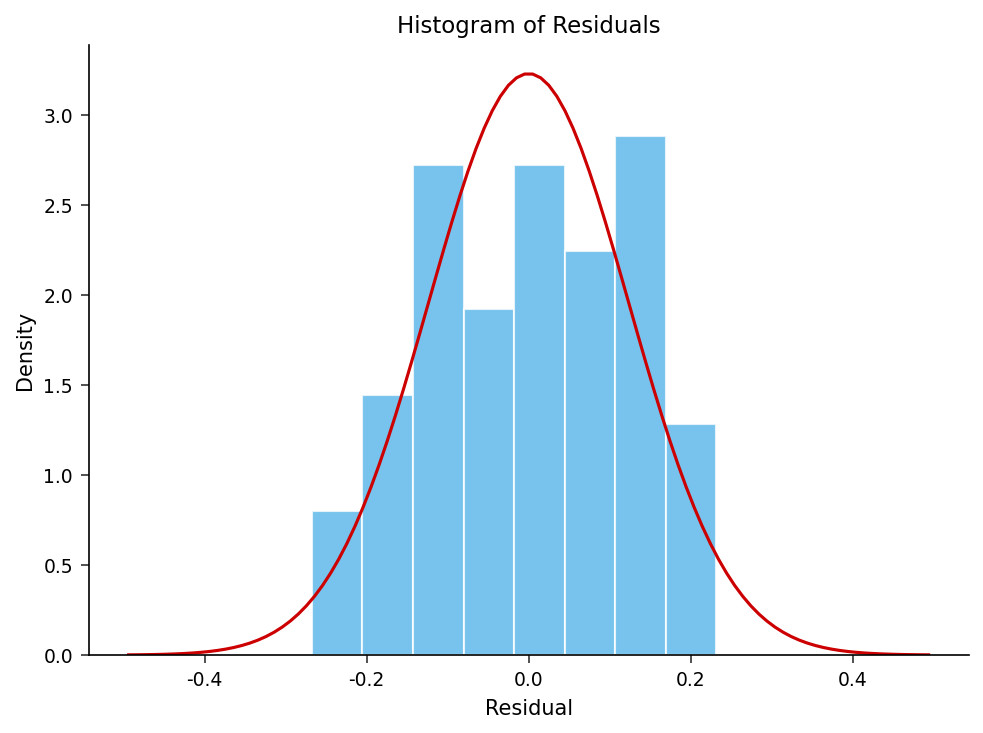

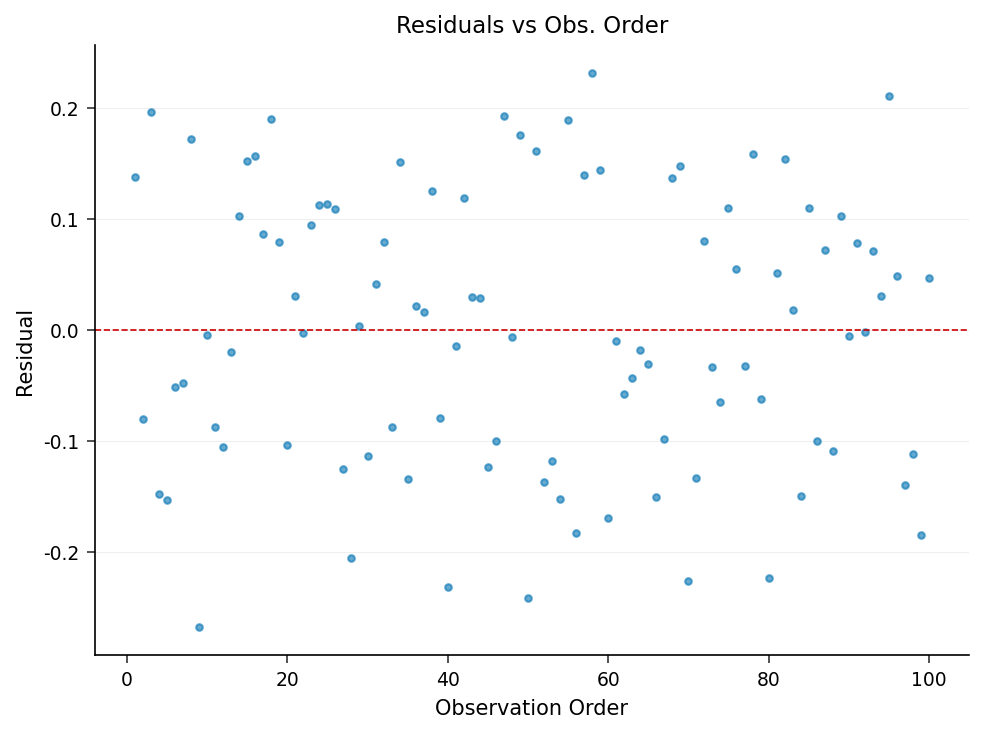

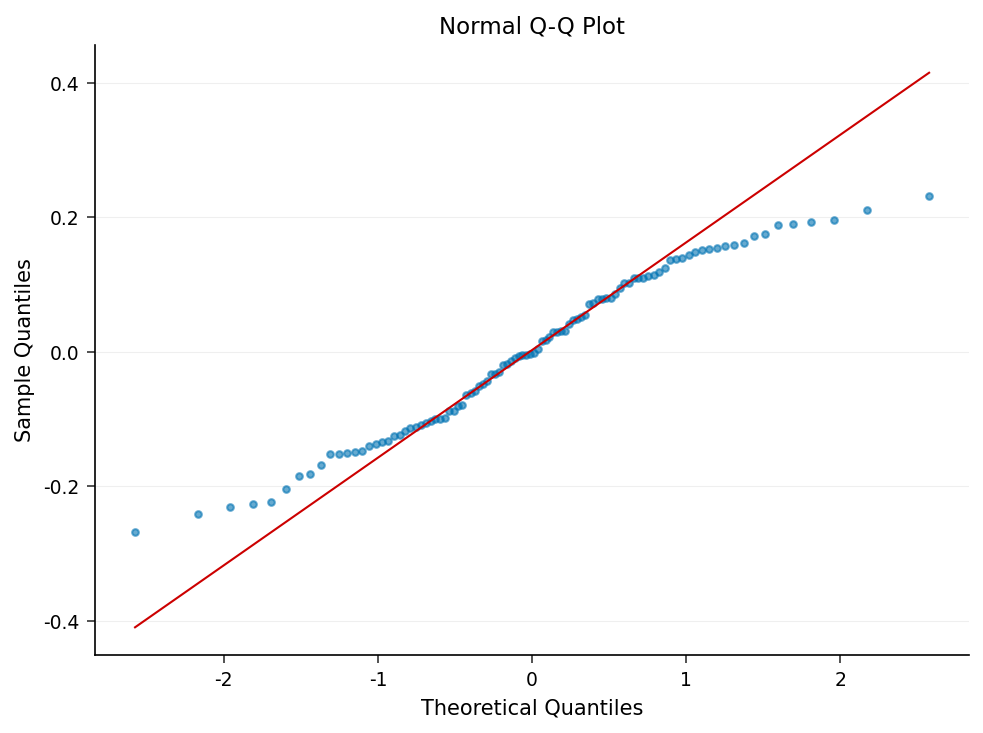

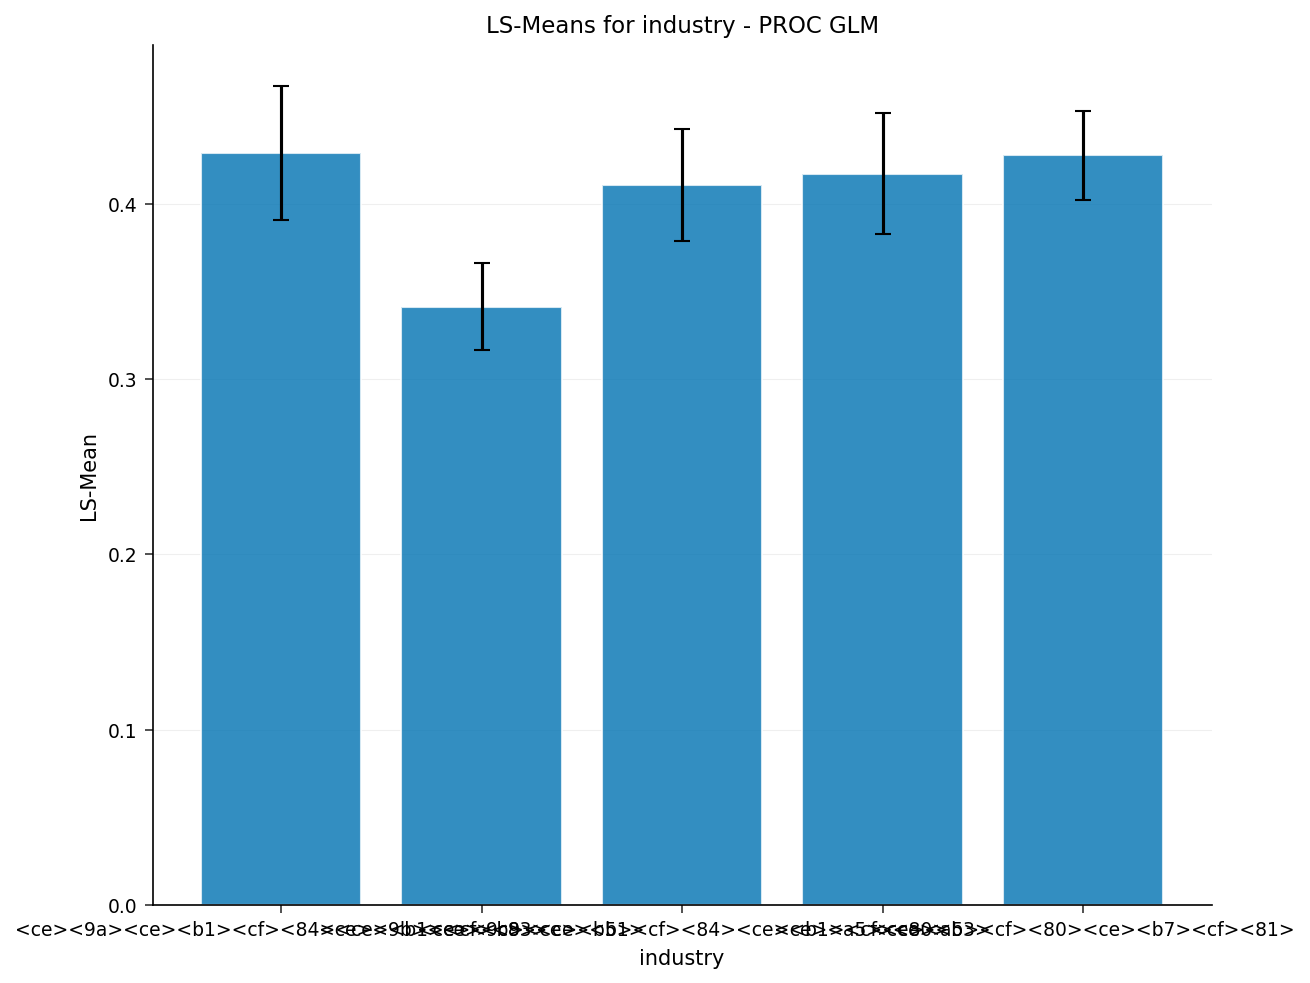

In [4]:
/* Χρήση ανά κλάδο δραστηριότητας, με προσαρμογή για τους οδηγούς */
ΔΙΑΔΙΚΑΣΙΑ GLM ΔΕΔΟΜΕΝΑ=credit_lines;
    ΚΛΑΣΗ industry;
    ΜΟΝΤΕΛΟ utilization_rate =
          industry dscr rev_volatility prior_util
          unemp_rate short_rate
          / SOLUTION ss3;
    LSMEANS industry / PDIFF ADJUST=TUKEY cl;
ΕΚΤΕΛΕΣΗ;
QUIT;

## 5. Ζώνη χρήσης για ακραίες καταστάσεις και οικονομικό κεφάλαιο

Ο σχεδιασμός κεφαλαίου χρειάζεται τις **ουρές** της κατανομής χρήσης, όχι μόνο τον μέσο. Επειδή τα κλασματικά εκατοστημόρια λαμβάνονται καλύτερα από την **PROC UNIVARIATE** παρά από την PROC MEANS, χρησιμοποιούμε `PCTLPTS=` για να εξαγάγουμε τα **εκατοστημόρια 2.5 και 97.5** της χρήσης. Η προκύπτουσα ζώνη ορίζει ένα εύλογο σενάριο χαμηλής/υψηλής άντλησης για δοκιμές ακραίων καταστάσεων του χρηματοδοτούμενου υπολοίπου.

In [5]:
/* Εκατοστημόρια χρήσης 2.5 / 97.5 για τη ζώνη στρες */
ΔΙΑΔΙΚΑΣΙΑ UNIVARIATE ΔΕΔΟΜΕΝΑ=credit_lines NOPRINT;
    ΜΕΤΑΒΛΗΤΗ utilization_rate;
    ΕΞΟΔΟΣ out=util_band
           mean=util_mean
           pctlpts=2.5 97.5
           pctlpre=util_p
           pctlname=lo hi;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=util_band noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ util_mean = "Μέση χρήση"
          util_plo  = "Εκατοστημόριο 2.5 (χαμηλό στρες)"
          util_phi  = "Εκατοστημόριο 97.5 (υψηλό στρες)";
ΕΚΤΕΛΕΣΗ;


         Μέση χρήση                          Εκατοστημόριο 2.5 (χαμηλό στρες)                         Εκατοστημόριο 97.5 (υψηλό στρες)
-------------------  --------------------------------------------------------  -------------------------------------------------------
           0.398452                                                    0.1467                                                   0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset util_band has 1 observations and 3 variables.
NOTE: PROC PRINT data=util_band

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Ερμηνεία και επόμενα βήματα

**Τι δείχνει το μοντέλο**

- **Η βαθμίδα κινδύνου καθοδηγεί τη χρηματοδοτούμενη έκθεση.** Το προφίλ της PROC MEANS δείχνει τη μέση χρήση να ανεβαίνει μονότονα από την ισχυρότερη βαθμίδα στην ασθενέστερη — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E). Επειδή το αντληθέν υπόλοιπο είναι η χρήση επί το δεσμευμένο όριο, οι ασθενέστερες βαθμίδες μετατρέπουν ένα μεγαλύτερο μερίδιο των δεσμεύσεών τους σε χρηματοδοτούμενα υπόλοιπα — το βασικό δεδομένο εισόδου για την έκθεση σε αθέτηση και το οικονομικό κεφάλαιο για ανακυκλούμενες γραμμές. (Το μέσο αντληθέν υπόλοιπο επίσης ανεβαίνει με τη βαθμίδα, κορυφώνοντας στη βαθμίδα D σε αυτό το δείγμα 100 γραμμών· η μικρή κυψέλη της βαθμίδας E με 9 γραμμές φέρει ένα πολύ μεγάλο όριο που παρασύρει τον μέσο δεσμευμένου ορίου της, ακριβώς το είδος συμπεριφοράς μικρής κυψέλης που το πλήρες βιβλίο θα εξομάλυνε.)
- **Τα θεμελιώδη μεγέθη του δανειολήπτη κυριαρχούν στην παλινδρόμηση.** Στην PROC REG, η **κάλυψη εξυπηρέτησης χρέους** φέρει τον μεγαλύτερο τυποποιημένο συντελεστή (-0.45) και είναι προστατευτική — κάθε επιπλέον μονάδα κάλυψης μειώνει τη χρήση κατά περίπου 0.11 (95% CL -0.152 έως -0.075). Η **προηγούμενη χρήση** είναι ο επόμενος ισχυρότερος παράγοντας (τυποποιημένος 0.41, εκτίμηση +0.38): οι γραμμές που είχαν αντληθεί έντονα προηγουμένως παραμένουν υψηλά χρησιμοποιούμενες. Η **μεταβλητότητα εσόδων** (+0.37, p = 0.021) και οι μακροοικονομικοί όροι — η **ανεργία** (+0.036, p = 0.009) και το **βραχυπρόθεσμο επιτόκιο** (+0.036, p = 0.036) — είναι όλοι θετικοί και σημαντικοί, οπότε μια ύφεση μηχανικά ανεβάζει τα χρηματοδοτούμενα υπόλοιπα σε όλο το χαρτοφυλάκιο. Όλα τα VIF βρίσκονται κάτω από 1.17, αρκετά κάτω από το συμβατικό κατώφλι του 10, επιβεβαιώνοντας ότι οι παράγοντες δεν είναι συγγραμμικοί, και τα διαστήματα CLB αποκλείουν το μηδέν για κάθε επίδραση εκτός από την ωρίμανση της γραμμής. Τα διαγνωστικά υπολοίπων συμπεριφέρονται καλά: τα υπόλοιπα διασκορπίζονται τυχαία γύρω από το μηδέν, το ιστόγραμμα είναι περίπου κανονικό, και το διάγραμμα Q-Q είναι κοντά στο γραμμικό με μόνο ήπια απόκλιση στις ουρές· το Cook's D επισημαίνει τέσσερις μετρίως επιδραστικές γραμμές (πάνω από 4/n = 0.04) που αξίζουν μια ματιά ελέγχου ποιότητας δεδομένων.
- **Ο κλάδος προσθέτει ένα οριακό υπολειπόμενο σήμα.** Αφού ελεγχθούν οι συμμεταβλητές δανειολήπτη και μακροοικονομίας, η συνολική επίδραση του κλάδου στην PROC GLM είναι μόνο οριακή (Type III F p = 0.060). Αλλά οι μέσοι ελαχίστων τετραγώνων προσαρμοσμένοι κατά Tukey εξακολουθούν να διαχωρίζουν τους κλάδους: οι **Κατασκευές** έχουν την υψηλότερη προσαρμοσμένη χρήση (0.492), ακολουθούμενες από τις **Υπηρεσίες** (0.428), με τη **Μεταποίηση** (0.394), την **Υγειονομική Περίθαλψη** (0.374) και το **Λιανικό Εμπόριο** (0.366) συγκεντρωμένα από κάτω. Οι έλεγχοι ανά ζεύγη επιβεβαιώνουν ότι οι Κατασκευές αντλούν σημαντικά περισσότερα από το **Λιανικό Εμπόριο** (διαφορά 0.126, p = 0.007) και την **Υγειονομική Περίθαλψη** (0.118, p = 0.024)· τα υπόλοιπα ανά ζεύγη κενά δεν είναι σημαντικά. Αυτό συνάδει με το πώς η ένταση κεφαλαίου κίνησης διαφέρει ανά τομέα και επισημαίνει τις Κατασκευές ως τον τομέα προς παρακολούθηση.

**Πώς να το χρησιμοποιήσετε**

- **Προβλέψτε χρηματοδοτούμενα υπόλοιπα** εφαρμόζοντας την παλινδρόμηση σε μελλοντικές μακροοικονομικές τροχιές (αυξανόμενη ανεργία, υψηλότερα βραχυπρόθεσμα επιτόκια) για να προβάλετε το αντληθέν υπόλοιπο του χαρτοφυλακίου σε κάθε σενάριο.
- **Ορίστε τη ζώνη ακραίας καταπόνησης οικονομικού κεφαλαίου** από τα εκατοστημόρια της PROC UNIVARIATE: η χρήση εύλογα κυμαίνεται από **0.121** (2.5) έως **0.744** (97.5) γύρω από έναν μέσο 0.404, καθορίζοντας το σενάριο χαμηλής/υψηλής άντλησης για μια ύφεση.
- **Διαφοροποιήστε όρια και τιμολόγηση** ανά βαθμίδα κινδύνου και ανά την αυξημένη προσαρμοσμένη άντληση των Κατασκευών, χρεώνοντας για την υψηλότερη αναμενόμενη χρήση — και υψηλότερη χρηματοδοτούμενη έκθεση — που ποσοτικοποιούν τα αποτελέσματα των MEANS και GLM.

**Επεκτάσεις**

Αντικαταστήστε τον σύνδεσμο OLS με μια παλινδρόμηση κλασματικής απόκρισης ή beta (PROC GLIMMIX / PROC NLMIXED) για να σεβαστείτε το όριο 0–1, προσθέστε μια τυχαία επίδραση δανειολήπτη για πολυπεριοδικά panel, και τροφοδοτήστε την προσαρμοσμένη χρήση απευθείας σε μια μηχανή ζημίας-δεδομένης-αθέτησης και οικονομικού κεφαλαίου. Η επανεκτέλεση στο πλήρες (χωρίς περιορισμό) βιβλίο θα σφίξει τις μικρές κυψέλες βαθμίδας κινδύνου και κλάδου και πιθανότατα θα οξύνει τον οριακό F-έλεγχο του κλάδου.